# 05 - Auditoria del pool de prediccion

Este notebook compara estrellas nuevas preparadas para prediccion contra WR conocidas y negativos SIMBAD. No aplica modelos y no genera predicciones.


## Objetivos

- Confirmar cobertura de tiles y documentar fallos.
- Verificar que las fuentes conocidas fueron excluidas del pool por `source_id`.
- Comparar candidatos Gaia contra las WR usadas por los modelos, no solo contra el conjunto relaxed completo.
- Separar visualmente tres conceptos distintos: bounds rectangulares enviados al ADQL, limites robustos usados localmente al ingerir tiles y puntos efectivamente conservados.


In [5]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Force an interactive notebook backend when running cells manually.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass
from IPython.display import Markdown, Image, display

try:
    import seaborn as sns
except ImportError:
    sns = None

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})

PALETTE = {
    "xgboost": "#2F6F9F",
    "random_forest": "#3A9D5D",
    "hist_gradient_boosting": "#B7791F",
    "logistic_regression": "#7B61A8",
    "wr": "#A8324A",
    "candidate": "#2F6F9F",
    "negative": "#6B7280",
    "muted": "#6B7280",
}

def require_path(path):
    path = Path(path)
    if not path.is_absolute():
        path = ROOT / path
    if not path.exists():
        raise FileNotFoundError(path)
    return path

def pct(value):
    return "-" if pd.isna(value) else f"{100 * float(value):.1f}%"

def model_display(row):
    variant = str(row.get("dataset_variant", ""))
    family = "Relaxed" if variant.startswith("relaxed") else "Strict"
    dataset = variant.replace("relaxed_", "").replace("strict_", "")
    dataset = dataset.replace("photometry", "Phot").replace("parallax_soft", "Parallax+").replace("poe_", "POE>=")
    feat = "+err" if str(row.get("feature_set", "")).endswith("error") else "base"
    model = {"xgboost": "XGB", "random_forest": "RF", "hist_gradient_boosting": "HGB", "logistic_regression": "LogReg"}.get(str(row.get("model", "")), str(row.get("model", "")))
    sampler = {"smote": "SMOTE", "smote_enn": "SMOTE-ENN", "none": "sin sampler"}.get(str(row.get("sampler", "")), str(row.get("sampler", "")))
    return f"{model} {sampler} | {family} {dataset} | {feat}"

def add_model_columns(df):
    out = df.copy()
    out["model_label"] = out.apply(model_display, axis=1)
    for k in [50, 100, 500, 1000]:
        c = f"holdout_wr_at_{k}"
        if c in out.columns:
            out[f"{c}_pct"] = out[c] / out["wr_holdout"].replace(0, np.nan)
    return out

def rank_models(df, k=100):
    return df.sort_values(
        [f"holdout_wr_at_{k}_pct", "holdout_average_precision", "holdout_recall_at_100", "holdout_f2_wr"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)

from wr_detector.pipelines.prediction_pool import load_prediction_pool_config, derive_color_envelope

pool_db = require_path("data/databases/prediction_pool.duckdb")
reference_path = require_path("data/processed/reference/wr_reference_relaxed_photometry_color_locus.parquet")
simbad_path = require_path("data/processed/simbad_negative/simbad_negative_relaxed_photometry_color_locus.parquet")
model_results_path = ROOT / "reports/tables/model_training_results.csv"
prediction_config = load_prediction_pool_config(ROOT / "configs/prediction_pool.yaml")
prediction_envelope = derive_color_envelope(prediction_config)
con = duckdb.connect(str(pool_db), read_only=True)


## Estado general del pool


In [6]:
tables = {r[0] for r in con.execute("SELECT table_name FROM information_schema.tables").fetchall()}
counts = []
for table in [
    "prediction_pool_sources",
    "prediction_pool_effective_tiles",
    "prediction_pool_tile_coverage",
    "prediction_pool_parquet_files",
    "prediction_pool_tiles",
    "prediction_pool_query_log",
    "prediction_pool_exclusions",
    "prediction_pool_known_sources",
]:
    if table in tables:
        counts.append({"table": table, "rows": int(con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0])})
display(pd.DataFrame(counts))

tile_status = con.execute("SELECT status, COUNT(*) AS tiles FROM prediction_pool_tiles GROUP BY status ORDER BY status").fetchdf()
display(tile_status)

if "prediction_pool_tile_coverage" in tables:
    coverage_status = con.execute("""
        SELECT coverage_role, COUNT(*) AS tiles, COALESCE(SUM(row_count), 0) AS rows
        FROM prediction_pool_tile_coverage
        GROUP BY coverage_role
        ORDER BY coverage_role
    """).fetchdf()
    display(coverage_status)

source_counts = con.execute("SELECT COUNT(*) AS rows, COUNT(DISTINCT source_id) AS distinct_source_ids FROM prediction_pool_sources").fetchdf()
source_counts["duplicate_rows"] = source_counts["rows"] - source_counts["distinct_source_ids"]
display(source_counts)


,table,rows
0,prediction_pool_sources,58037788
1,prediction_pool_effective_tiles,675
2,prediction_pool_tile_coverage,684
3,prediction_pool_parquet_files,675
4,prediction_pool_tiles,684
5,prediction_pool_query_log,693
6,prediction_pool_exclusions,26866
7,prediction_pool_known_sources,80166


,status,tiles
0,completed,675
1,skipped,9


,coverage_role,tiles,rows
0,effective_tile,675,58037788.0
1,subdivided_parent,9,0.0


,rows,distinct_source_ids,duplicate_rows
0,58037788,58037786,2


## Tiles fallidos


In [7]:
if "prediction_pool_tile_coverage" in tables:
    incomplete = con.execute("""
        SELECT tile_id, ra_min, ra_max, dec_min, dec_max, status, row_count, error_message, coverage_role
        FROM prediction_pool_tile_coverage
        WHERE NOT coverage_terminal
        ORDER BY ra_min, dec_min
    """).fetchdf()
    subdivided = con.execute("""
        SELECT tile_id, ra_min, ra_max, dec_min, dec_max, status, error_message
        FROM prediction_pool_tile_coverage
        WHERE coverage_role = 'subdivided_parent'
        ORDER BY ra_min, dec_min
    """).fetchdf()
else:
    incomplete = con.execute("""
        SELECT tile_id, ra_min, ra_max, dec_min, dec_max, status, row_count, error_message, 'incomplete' AS coverage_role
        FROM prediction_pool_tiles
        WHERE status <> 'completed'
        ORDER BY ra_min, dec_min
    """).fetchdf()
    subdivided = pd.DataFrame()

display(Markdown("**Tiles no terminales:**"))
display(incomplete)
display(Markdown("**Tiles padre reemplazados por subtiles:**"))
display(subdivided)

effective = int(con.execute("SELECT COUNT(*) FROM prediction_pool_effective_tiles").fetchone()[0]) if "prediction_pool_effective_tiles" in tables else int(tile_status.loc[tile_status["status"].eq("completed"), "tiles"].sum())
terminal = int(con.execute("SELECT COUNT(*) FROM prediction_pool_tile_coverage WHERE coverage_terminal").fetchone()[0]) if "prediction_pool_tile_coverage" in tables else effective
registered = int(con.execute("SELECT COUNT(*) FROM prediction_pool_tiles").fetchone()[0])
display(Markdown(f"**Cobertura:** `{terminal}/{registered}` tiles registrados en estado terminal; `{effective}` tiles efectivos con parquet."))


**Tiles no terminales:**

,tile_id,ra_min,ra_max,dec_min,dec_max,status,row_count,error_message,coverage_role


**Tiles padre reemplazados por subtiles:**

,tile_id,ra_min,ra_max,dec_min,dec_max,status,error_message
0,ra260p00_270p00__dec-70p00_-60p00,260.0,270.0,-70.0,-60.0,skipped,subdivided_into_subtiles
1,ra260p00_270p00__dec-60p00_-50p00,260.0,270.0,-60.0,-50.0,skipped,subdivided_into_subtiles
2,ra260p00_270p00__dec-30p00_-20p00,260.0,270.0,-30.0,-20.0,skipped,subdivided_into_subtiles
3,ra260p00_270p00__dec-20p00_-10p00,260.0,270.0,-20.0,-10.0,skipped,subdivided_into_subtiles
4,ra270p00_280p00__dec-70p00_-60p00,270.0,280.0,-70.0,-60.0,skipped,subdivided_into_subtiles
5,ra270p00_280p00__dec-60p00_-50p00,270.0,280.0,-60.0,-50.0,skipped,subdivided_into_subtiles
6,ra270p00_280p00__dec-30p00_-20p00,270.0,280.0,-30.0,-20.0,skipped,subdivided_into_subtiles
7,ra270p00_280p00__dec-20p00_-10p00,270.0,280.0,-20.0,-10.0,skipped,subdivided_into_subtiles
8,ra280p00_290p00__dec-30p00_-20p00,280.0,290.0,-30.0,-20.0,skipped,subdivided_into_subtiles


**Cobertura:** `684/684` tiles registrados en estado terminal; `675` tiles efectivos con parquet.

## Mapa RA-Dec de cobertura y densidad


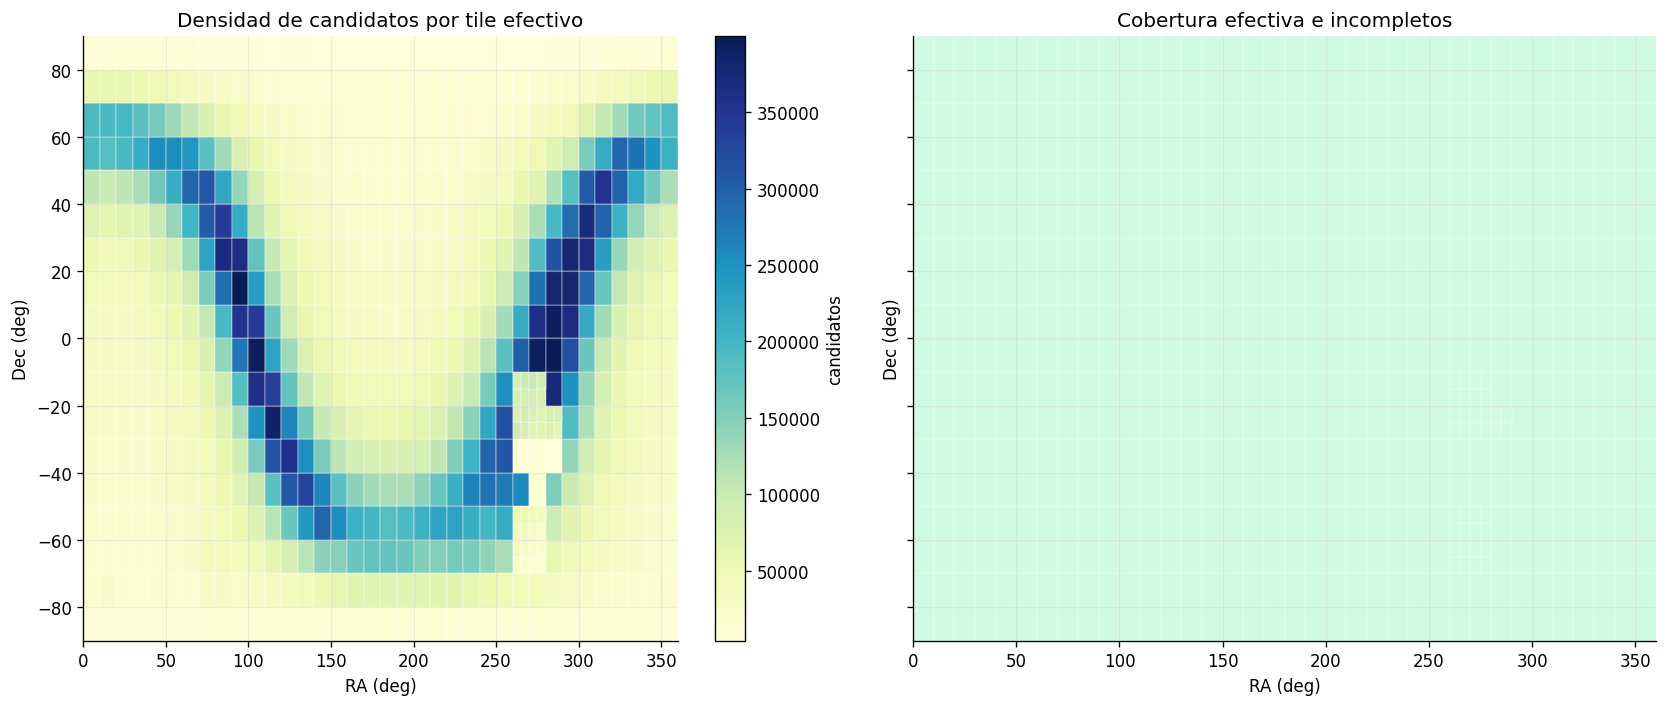

In [8]:
if "prediction_pool_effective_tiles" in tables:
    effective_tiles = con.execute("""
        SELECT tile_id, ra_min, ra_max, dec_min, dec_max, row_count
        FROM prediction_pool_effective_tiles
        ORDER BY dec_min, ra_min
    """).fetchdf()
else:
    effective_tiles = con.execute("""
        SELECT tile_id, ra_min, ra_max, dec_min, dec_max, row_count
        FROM prediction_pool_tiles
        WHERE status = 'completed'
        ORDER BY dec_min, ra_min
    """).fetchdf()

if "prediction_pool_tile_coverage" in tables:
    incomplete_tiles = con.execute("""
        SELECT tile_id, ra_min, ra_max, dec_min, dec_max, row_count, coverage_role
        FROM prediction_pool_tile_coverage
        WHERE NOT coverage_terminal
        ORDER BY dec_min, ra_min
    """).fetchdf()
else:
    incomplete_tiles = con.execute("""
        SELECT tile_id, ra_min, ra_max, dec_min, dec_max, row_count, 'incomplete' AS coverage_role
        FROM prediction_pool_tiles
        WHERE status <> 'completed'
        ORDER BY dec_min, ra_min
    """).fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

if effective_tiles.empty:
    axes[0].text(0.5, 0.5, "Sin tiles efectivos", transform=axes[0].transAxes, ha="center", va="center")
else:
    values = effective_tiles["row_count"].fillna(0).astype(float)
    norm = plt.Normalize(vmin=float(values.min()), vmax=float(values.max()))
    cmap = plt.cm.YlGnBu
    for row in effective_tiles.itertuples(index=False):
        value = 0 if pd.isna(row.row_count) else float(row.row_count)
        rect = Rectangle(
            (row.ra_min, row.dec_min),
            row.ra_max - row.ra_min,
            row.dec_max - row.dec_min,
            facecolor=cmap(norm(value)),
            edgecolor="white",
            linewidth=0.25,
        )
        axes[0].add_patch(rect)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=axes[0], label="candidatos")

# Draw all effective tiles as light coverage on the right, then overlay incomplete ones.
for row in effective_tiles.itertuples(index=False):
    axes[1].add_patch(Rectangle((row.ra_min, row.dec_min), row.ra_max - row.ra_min, row.dec_max - row.dec_min, facecolor="#D1FAE5", edgecolor="white", linewidth=0.2))
for row in incomplete_tiles.itertuples(index=False):
    axes[1].add_patch(Rectangle((row.ra_min, row.dec_min), row.ra_max - row.ra_min, row.dec_max - row.dec_min, facecolor="#DC2626", edgecolor="black", linewidth=0.5))

for ax in axes:
    ax.set_xlim(0, 360)
    ax.set_ylim(-90, 90)
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("Dec (deg)")
    ax.set_aspect("auto")

axes[0].set_title("Densidad de candidatos por tile efectivo")
axes[1].set_title("Cobertura efectiva e incompletos")
plt.tight_layout()
plt.show()


## Exclusiones y redundancia con fuentes conocidas


In [9]:
exclusions = con.execute("SELECT exclusion_label, COUNT(*) AS rows FROM prediction_pool_exclusions GROUP BY exclusion_label ORDER BY exclusion_label").fetchdf()
display(exclusions)

if "prediction_pool_known_sources" in tables:
    overlap = con.execute('''
        SELECT k.exclusion_label, COUNT(*) AS overlap_rows
        FROM prediction_pool_sources p
        INNER JOIN prediction_pool_known_sources k USING (source_id)
        GROUP BY k.exclusion_label
        ORDER BY k.exclusion_label
    ''').fetchdf()
    display(overlap)
    if overlap.empty or overlap["overlap_rows"].sum() == 0:
        display(Markdown("No quedan fuentes conocidas dentro de `prediction_pool_sources`."))
else:
    display(Markdown("No existe `prediction_pool_known_sources`; se usa `prediction_pool_exclusions` como evidencia de filtrado."))


,exclusion_label,rows
0,known_non_wr_simbad,26640
1,known_wr,226


,exclusion_label,overlap_rows


No quedan fuentes conocidas dentro de `prediction_pool_sources`.

## Muestra de candidatos Gaia


In [10]:
SAMPLE_N = 120000
candidate = con.execute(f'''
    SELECT source_id, ra, dec, G_BP, G_RP, BP_RP, J_H, J_K, H_K, W1_W2, color_locus_keep, color_locus_outlier_plane_count
    FROM prediction_pool_sources
    USING SAMPLE reservoir({SAMPLE_N} ROWS) REPEATABLE (42)
''').fetchdf()

if model_results_path.exists():
    model_results = add_model_columns(pd.read_csv(model_results_path))
    model_results = rank_models(model_results, k=100)
    MODEL_VARIANT = str(model_results.iloc[0]["dataset_variant"])
    MODEL_VARIANT_NOTE = "variante del mejor modelo vigente"
else:
    MODEL_VARIANT = "strict_poe_2"
    MODEL_VARIANT_NOTE = "fallback hasta reentrenar modelos filtrados"
modeling_path = ROOT / "data/processed/modeling" / f"{MODEL_VARIANT}_reduced.parquet"
model_wr = pd.read_parquet(modeling_path)
model_wr = model_wr[model_wr["target"].eq(1)].copy()
wr_relaxed = pd.read_parquet(reference_path)
simbad = pd.read_parquet(simbad_path, columns=["source_id", "G_BP", "G_RP", "BP_RP", "J_H", "J_K", "H_K", "W1_W2", "color_locus_keep", "simbad_main_type", "simbad_query_type"])

print(f"Muestra candidatos: {len(candidate):,}")
print(f"WR usadas por modelos ({MODEL_VARIANT}, {MODEL_VARIANT_NOTE}): {len(model_wr):,}")
print(model_wr.groupby("modeling_split")["target"].agg(rows="size", wr="sum"))
print(f"WR relaxed_photometry completa: {len(wr_relaxed):,}")
print(f"SIMBAD relaxed_photometry: {len(simbad):,}")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Muestra candidatos: 120,000
WR usadas por modelos (strict_photometry, variante del mejor modelo vigente): 292
                rows   wr
modeling_split           
holdout           62   62
train            230  230
WR relaxed_photometry completa: 347
SIMBAD relaxed_photometry: 66,787


## Color-color: candidatos vs WR de modelado

El ADQL actual usa bounds rectangulares por color. Las rectas robustas se aplican localmente durante la ingesta y el criterio agregado conserva objetos con menos de 2 planos outlier. Por eso el borde de la nube no tiene por que coincidir con la linea inferior de un plano individual.


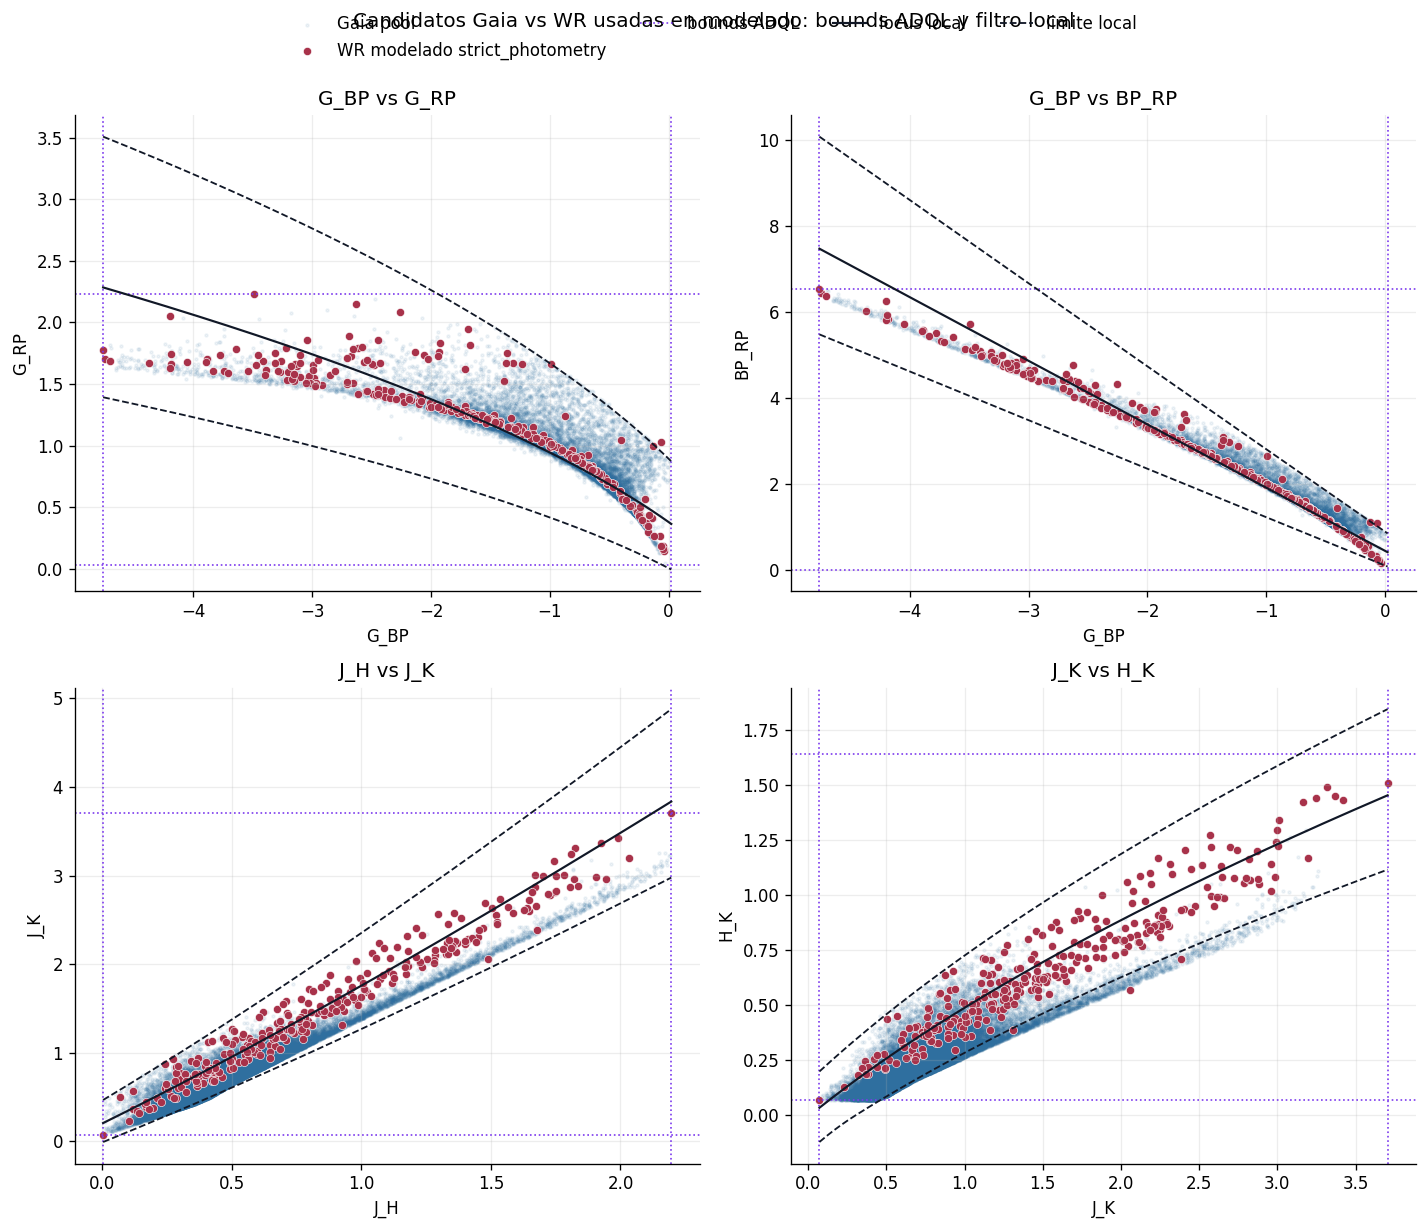

In [11]:
def signed_log1p(x):
    x = np.asarray(x, dtype="float64")
    return np.sign(x) * np.log1p(np.abs(x))

def inv_signed_log1p(z):
    z = np.asarray(z, dtype="float64")
    return np.sign(z) * np.expm1(np.abs(z))

def envelope_fit(x, y):
    for fit in prediction_envelope["fits"]:
        if fit["x"] == x and fit["y"] == y:
            return fit
    return None

def draw_prediction_locus(ax, x, y):
    fit = envelope_fit(x, y)
    if fit is None:
        return
    bounds = prediction_envelope["color_bounds"].get(x)
    if not bounds:
        return
    xs = np.linspace(bounds["min"], bounds["max"], 240)
    slope = (float(fit["slope_min"]) + float(fit["slope_max"])) / 2
    intercept = (float(fit["intercept_min"]) + float(fit["intercept_max"])) / 2
    threshold = float(fit["threshold_max"])
    pred = intercept + slope * signed_log1p(xs)
    ax.plot(xs, inv_signed_log1p(pred), color="#111827", lw=1.3, label="locus local")
    ax.plot(xs, inv_signed_log1p(pred + threshold), color="#111827", lw=1.1, ls="--", label="limite local")
    ax.plot(xs, inv_signed_log1p(pred - threshold), color="#111827", lw=1.1, ls="--")

def draw_query_bounds(ax, x, y):
    xb = prediction_envelope["color_bounds"].get(x)
    yb = prediction_envelope["color_bounds"].get(y)
    if xb:
        ax.axvline(xb["min"], color="#7C3AED", lw=1, ls=":", label="bounds ADQL")
        ax.axvline(xb["max"], color="#7C3AED", lw=1, ls=":")
    if yb:
        ax.axhline(yb["min"], color="#7C3AED", lw=1, ls=":")
        ax.axhline(yb["max"], color="#7C3AED", lw=1, ls=":")

planes = [("G_BP", "G_RP"), ("G_BP", "BP_RP"), ("J_H", "J_K"), ("J_K", "H_K")]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (x, y) in zip(axes.ravel(), planes):
    c = candidate[[x, y, "color_locus_outlier_plane_count"]].dropna()
    if len(c) > 40000:
        c = c.sample(40000, random_state=42)
    ax.scatter(c[x], c[y], s=3, alpha=0.07, color=PALETTE["candidate"], rasterized=True, label="Gaia pool")
    ax.scatter(model_wr[x], model_wr[y], s=24, color=PALETTE["wr"], edgecolor="white", linewidth=0.35, label=f"WR modelado {MODEL_VARIANT}")
    draw_query_bounds(ax, x, y)
    draw_prediction_locus(ax, x, y)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")
handles, labels = axes[0, 0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), frameon=False, loc="upper center", ncol=4)
fig.suptitle("Candidatos Gaia vs WR usadas en modelado: bounds ADQL y filtro local", y=1.02)
plt.tight_layout()
plt.show()


## Comparacion con SIMBAD conocido


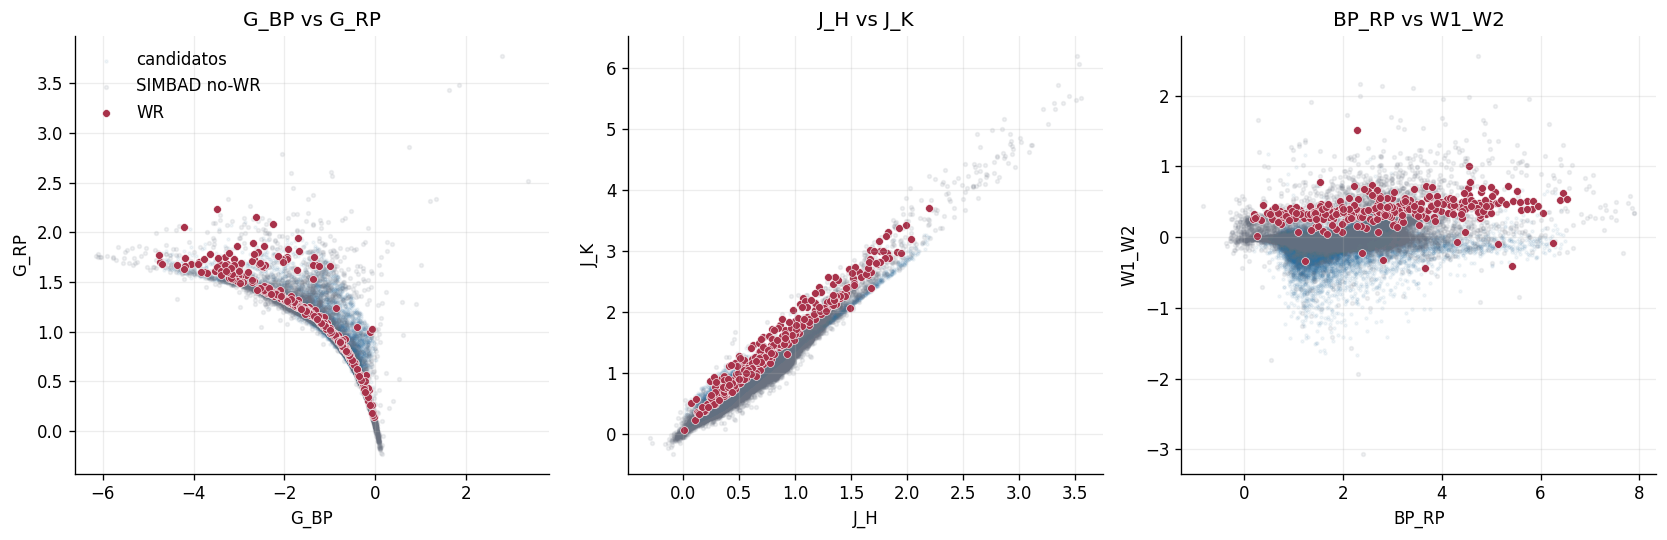

,simbad_main_type,rows
0,LP*,9685
1,Em*,9192
2,C*,9060
3,RG*,8940
4,EB*,8005
5,Y*O,6521
6,Er*,5264
7,TT*,5029
8,AB*,2264
9,Be*,1913


In [12]:
planes = [("G_BP", "G_RP"), ("J_H", "J_K"), ("BP_RP", "W1_W2")]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, (x, y) in zip(axes, planes):
    c = candidate[[x, y]].dropna()
    if len(c) > 25000:
        c = c.sample(25000, random_state=42)
    s = simbad[[x, y]].dropna()
    if len(s) > 12000:
        s = s.sample(12000, random_state=42)
    ax.scatter(c[x], c[y], s=3, alpha=0.06, color=PALETTE["candidate"], rasterized=True, label="candidatos")
    ax.scatter(s[x], s[y], s=5, alpha=0.10, color=PALETTE["negative"], rasterized=True, label="SIMBAD no-WR")
    ax.scatter(model_wr[x], model_wr[y], s=22, color=PALETTE["wr"], edgecolor="white", linewidth=0.35, label="WR")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

display(simbad["simbad_main_type"].fillna("missing").value_counts().head(15).rename_axis("simbad_main_type").reset_index(name="rows"))


## Reintento de tiles no terminales

El pipeline recorre solo tiles cuyo estado no sea `completed` ni `skipped`. Los tiles `skipped` con `error_message = subdivided_into_subtiles` son padres reemplazados por subtiles y no deben reintentarse directamente.

Para reintentar tiles realmente no terminales (`failed`, `pending`, `running` obsoleto), corre nuevamente:

```powershell
wr-detector build-prediction-pool --config configs/prediction_pool.yaml
```

La lista operativa de parquet a recorrer es `prediction_pool_effective_tiles`. La vista `prediction_pool_tile_coverage` distingue `effective_tile`, `subdivided_parent` e `incomplete`, de modo que notebooks y scoring puedan tratar padres subdivididos como cobertura terminal sin duplicar ?rea de cielo.


In [13]:
con.close()
